# Analisis Kualitas Udara — Wilayah Studi (Madura, Jawa Timur)
**Periode data:** 24 Agustus 2025 – 24 Agustus 2026

**Sumber data:** Copernicus Data Space Ecosystem (CDSE) — openEO API — Sentinel-5P (TROPOMI)

Notebook ini dijalankan di **CDSE JupyterLab** dengan kernel **OpenEO** (`openeo.dataspace.copernicus.eu`).


## 1. Business Understanding

**Tujuan bisnis:** Mengamati dan memahami kualitas udara di wilayah studi melalui data konsentrasi gas-gas polutan utama, yaitu:

- **NO2** (Nitrogen Dioksida) — terkait emisi kendaraan bermotor & pembakaran bahan bakar fosil, indikator aktivitas transportasi/industri.
- **CO** (Karbon Monoksida) — hasil pembakaran tidak sempurna, terkait kebakaran, industri, kendaraan.
- **CH4** (Metana) — gas rumah kaca, terkait aktivitas pertanian (sawah, peternakan), lahan gambut, dan kebocoran gas.
- **SO2** (Sulfur Dioksida) — terkait pembakaran batu bara/bahan bakar mengandung sulfur, aktivitas industri & pembangkit listrik.

Keempat gas ini menjadi indikator utama baik-buruknya kualitas udara suatu wilayah. Peningkatan konsentrasi yang signifikan pada salah satu atau beberapa gas ini biasanya berkorelasi dengan aktivitas manusia (industri, transportasi, pertanian) atau kejadian tertentu (kebakaran, cuaca ekstrem).

**Pertanyaan yang ingin dijawab:**
1. Bagaimana pola/tren konsentrasi NO2, CO, CH4, dan SO2 di wilayah studi selama periode 24 Agustus 2025 – 24 Agustus 2026?
2. Apakah ada anomali (outlier) yang mengindikasikan kejadian pencemaran tertentu?
3. Seberapa lengkap data yang tersedia (missing value) dan seberapa "bersih" datanya (noise)?


## 2. Data Understanding

### 2.1 Sumber & Metode Pengumpulan Data

Data dikumpulkan dari koleksi **`SENTINEL_5P_L2`** (Sentinel-5P Level 2) yang di-host oleh Sentinel Hub dan dapat diakses melalui **openEO API** di Copernicus Data Space Ecosystem. Koleksi ini berisi band-band gas atmosfer termasuk `NO2`, `CO`, `CH4`, dan `SO2`.

> **Catatan:** openEO/Sentinel Hub API saat ini hanya bisa memuat **satu band (gas) per request**, sehingga setiap gas diambil dengan `load_collection` terpisah.

### 2.2 Wilayah Studi (Area of Interest)

Wilayah studi didefinisikan melalui polygon GeoJSON (dibuat dengan geojson.io), berupa bounding box di wilayah Madura, Jawa Timur:


In [ ]:
# Install dependencies (jalankan sel ini dulu, sekali saja)
# Kalau kamu memakai kernel "OpenEO" bawaan CDSE JupyterLab, openeo biasanya sudah terpasang
# dan baris ini bisa dilewati / akan langsung selesai cepat karena sudah ada.
# Kalau kamu menjalankan di Google Colab atau Jupyter biasa, WAJIB jalankan ini dulu.
%pip install openeo pandas matplotlib seaborn folium --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.3 MB/s eta 0:00:00


In [ ]:
import openeo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


In [ ]:
# --- Wilayah studi (AOI) - diambil dari geojson.io ---
aoi_geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [113.5196999, -7.0215453],
                    [113.573856, -7.0215453],
                    [113.573856, -7.0594754],
                    [113.5196999, -7.0594754],
                    [113.5196999, -7.0215453]
                ]]
            }
        }
    ]
}

aoi_geometry = aoi_geojson["features"][0]["geometry"]

# bounding box untuk spatial_extent openEO
bbox = {
    "west": 113.5196999,
    "south": -7.0594754,
    "east": 113.573856,
    "north": -7.0215453,
}

# rentang waktu tugas
start_date = "2025-08-24"
end_date = "2026-08-24"


In [ ]:
# Visualisasi peta wilayah studi
import folium

center_lat = (bbox["north"] + bbox["south"]) / 2
center_lon = (bbox["east"] + bbox["west"]) / 2

m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles="OpenStreetMap")
folium.GeoJson(aoi_geojson, name="Wilayah Studi",
               style_function=lambda x: {"color": "red", "fillColor": "red", "fillOpacity": 0.2}).add_to(m)
folium.LayerControl().add_to(m)
m  # tampilkan peta interaktif


### 2.3 Autentikasi & Koneksi ke openEO

Jalankan sel di bawah ini — akan muncul instruksi login (OIDC) melalui akun Copernicus Data Space Ecosystem kamu.


In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu")
connection = connection.authenticate_oidc()


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=HEMY-CPLY 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


### 2.4 Pengambilan Data per Polutan

Untuk tiap gas (`NO2`, `CO`, `CH4`, `SO2`):
1. `load_collection` — ambil data dari `SENTINEL_5P_L2` untuk band tersebut, di wilayah & periode studi.
2. `aggregate_temporal_period(period="day")` — gabungkan jadi satu nilai per hari (menghindari banyak nilai per hari akibat overlap orbit satelit).
3. `aggregate_spatial(reducer="mean")` — rata-ratakan nilai di seluruh wilayah studi, menghasilkan **time series** (satu nilai per hari).
4. `execute_batch` — jalankan job di server CDSE lalu unduh hasilnya (format JSON).


In [ ]:
os.makedirs("data", exist_ok=True)

def fetch_pollutant_timeseries(band_name):
    """Ambil time series rata-rata harian untuk satu band gas polutan."""
    cube = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[start_date, end_date],
        spatial_extent=bbox,
        bands=[band_name],
    )
    cube = cube.aggregate_temporal_period(reducer="mean", period="day")
    cube = cube.aggregate_spatial(reducer="mean", geometries=aoi_geometry)

    out_dir = f"data/{band_name.lower()}"
    os.makedirs(out_dir, exist_ok=True)

    job = cube.execute_batch(out_format="JSON", title=f"{band_name}_timeseries")
    job.get_results().download_files(out_dir)
    return out_dir

bands = ["NO2", "CO", "CH4", "SO2"]
output_dirs = {}

for band in bands:
    print(f"Memproses band: {band} ...")
    output_dirs[band] = fetch_pollutant_timeseries(band)
    print(f"  -> selesai, hasil disimpan di: {output_dirs[band]}")


Memproses band: NO2 ...
0:00:00 Job 'j-26090317394448f395e207a8ebdc68f7': send 'start'
0:00:10 Job 'j-26090317394448f395e207a8ebdc68f7': queued (progress 0%)
0:00:15 Job 'j-26090317394448f395e207a8ebdc68f7': queued (progress 0%)
0:00:22 Job 'j-26090317394448f395e207a8ebdc68f7': queued (progress 0%)
0:00:30 Job 'j-26090317394448f395e207a8ebdc68f7': queued (progress 0%)
0:00:40 Job 'j-26090317394448f395e207a8ebdc68f7': queued (progress 0%)
0:00:53 Job 'j-26090317394448f395e207a8ebdc68f7': queued (progress 0%)
0:01:08 Job 'j-26090317394448f395e207a8ebdc68f7': queued (progress 0%)
0:01:28 Job 'j-26090317394448f395e207a8ebdc68f7': running (progress N/A)
0:01:52 Job 'j-26090317394448f395e207a8ebdc68f7': running (progress N/A)
0:02:22 Job 'j-26090317394448f395e207a8ebdc68f7': running (progress N/A)
0:02:59 Job 'j-26090317394448f395e207a8ebdc68f7': running (progress N/A)
0:03:46 Job 'j-26090317394448f395e207a8ebdc68f7': running (progress N/A)
0:04:45 Job 'j-26090317394448f395e207a8ebdc68f7': r

In [ ]:
def load_timeseries_json(out_dir, band_name):
    """Parse file JSON hasil openEO menjadi DataFrame dengan kolom [date, band_name]."""
    # PENTING: jangan ambil job-results.json (metadata STAC) - ambil timeseries.json saja
    json_files = [f for f in os.listdir(out_dir) if f.endswith(".json") and f != "job-results.json"]
    if not json_files:
        raise FileNotFoundError(f"Tidak ada file timeseries.json di {out_dir}")

    with open(os.path.join(out_dir, json_files[0])) as f:
        raw = json.load(f)

    records = []
    for date_str, values in raw.items():
        val = None
        if values and len(values) > 0 and len(values[0]) > 0:
            val = values[0][0]
        records.append({"date": date_str, band_name: val})

    df = pd.DataFrame(records)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    return df

# Muat masing-masing time series
df_no2 = load_timeseries_json(output_dirs["NO2"], "NO2")
df_co  = load_timeseries_json(output_dirs["CO"], "CO")
df_ch4 = load_timeseries_json(output_dirs["CH4"], "CH4")
df_so2 = load_timeseries_json(output_dirs["SO2"], "SO2")

# Gabungkan semua polutan jadi satu tabel berdasarkan tanggal
df = df_no2.merge(df_co, on="date", how="outer") \
           .merge(df_ch4, on="date", how="outer") \
           .merge(df_so2, on="date", how="outer") \
           .sort_values("date").reset_index(drop=True)

df.to_csv("data/air_quality_combined.csv", index=False)
df.head()

,date,NO2,CO,CH4,SO2
0,2025-08-23 00:00:00+00:00,NaN,NaN,NaN,NaN
1,2025-08-24 00:00:00+00:00,0.000011,0.026595,NaN,NaN
2,2025-08-25 00:00:00+00:00,-0.000009,NaN,NaN,0.000315
3,2025-08-26 00:00:00+00:00,-0.000006,NaN,NaN,0.000220
4,2025-08-27 00:00:00+00:00,0.000014,0.020765,NaN,0.000185


In [ ]:
# Simpan tiap polutan jadi file CSV terpisah
df_no2.to_csv("data/NO2.csv", index=False)
df_co.to_csv("data/CO.csv", index=False)
df_ch4.to_csv("data/CH4.csv", index=False)
df_so2.to_csv("data/SO2.csv", index=False)

print("Selesai disimpan:")
print(df_no2.shape, "-> NO2.csv")
print(df_co.shape, "-> CO.csv")
print(df_ch4.shape, "-> CH4.csv")
print(df_so2.shape, "-> SO2.csv")

Selesai disimpan:
(366, 2) -> NO2.csv
(366, 2) -> CO.csv
(366, 2) -> CH4.csv
(366, 2) -> SO2.csv


In [ ]:
from google.colab import files
files.download("data/NO2.csv")
files.download("data/CO.csv")
files.download("data/CH4.csv")
files.download("data/SO2.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Eksplorasi Data (Exploratory Data Analysis)

### 3.1 Visualisasi Data — Tren Time Series


**Catatan:** Grafik di bawah ini sengaja menampilkan data harian **mentah** (belum diisi/gap-filled), sehingga garisnya terlihat terputus-putus mengikuti pola hari-hari yang datanya tersedia. Ini untuk menunjukkan kondisi data asli sebelum diproses. Untuk versi yang lebih mudah dibaca (setelah gap-filling dan dihaluskan dengan rata-rata mingguan), lihat grafik di bagian 3.6.

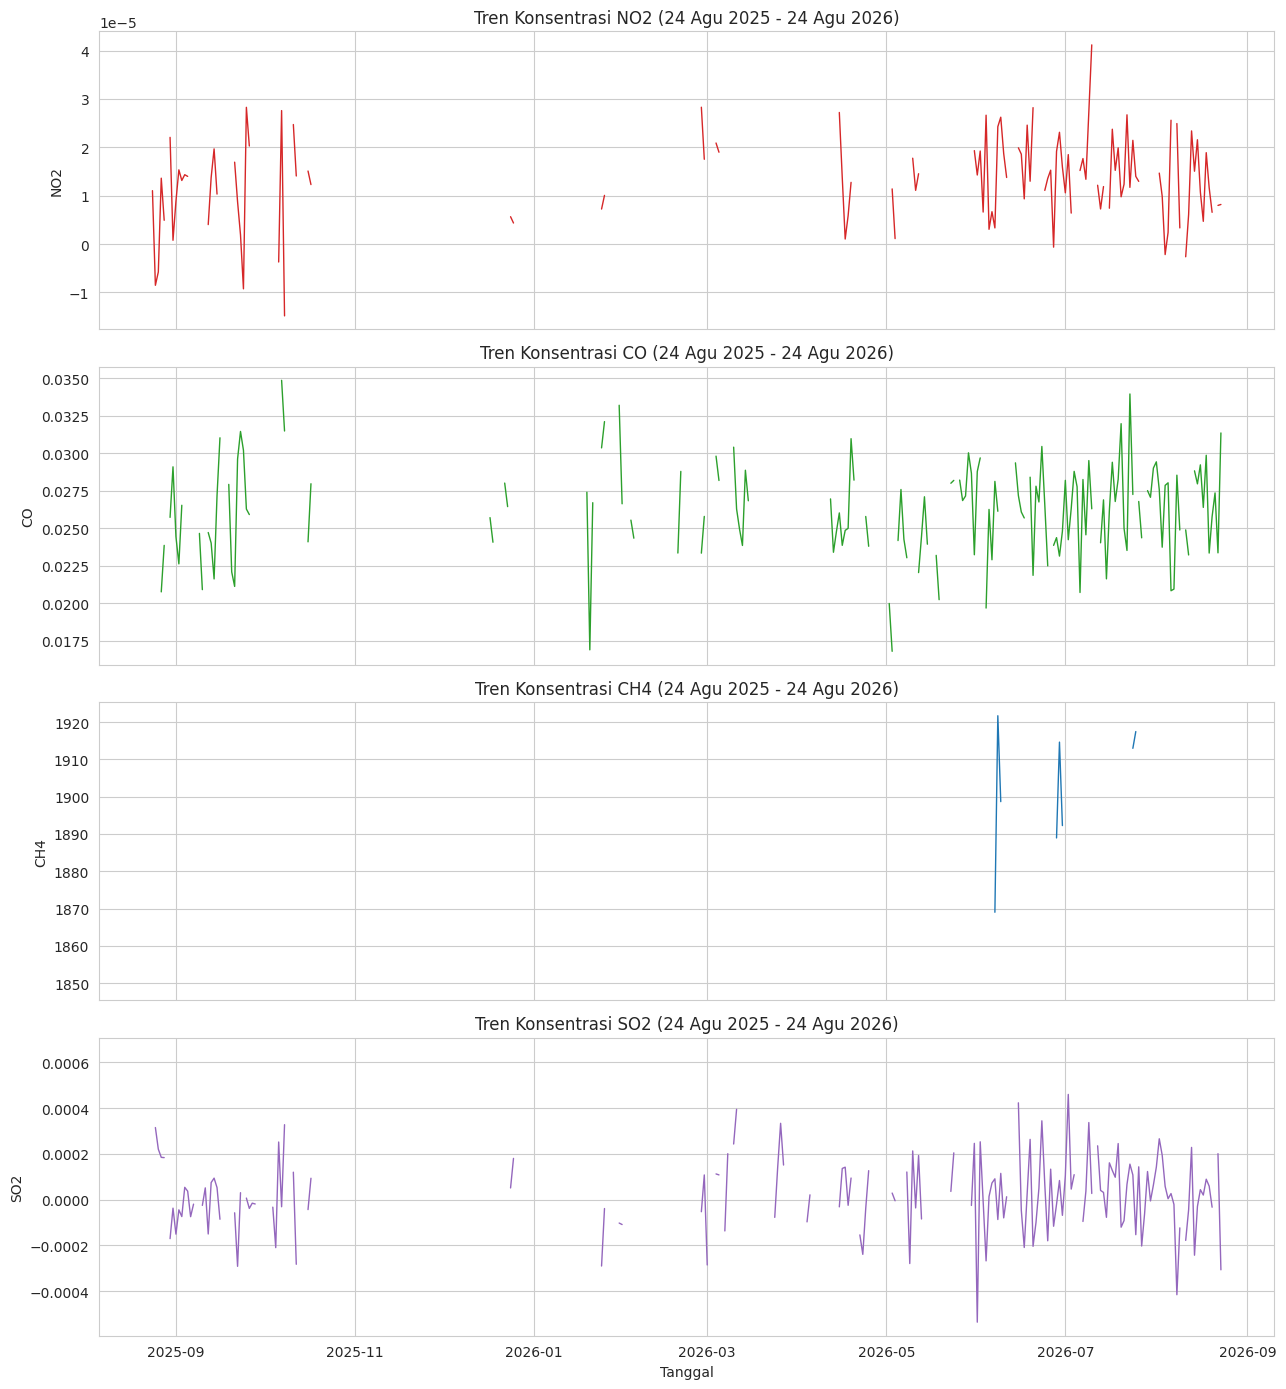

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True)
pollutants = ["NO2", "CO", "CH4", "SO2"]
colors = ["#d62728", "#2ca02c", "#1f77b4", "#9467bd"]

for ax, pol, c in zip(axes, pollutants, colors):
    ax.plot(df["date"], df[pol], color=c, linewidth=1)
    ax.set_ylabel(pol)
    ax.set_title(f"Tren Konsentrasi {pol} (24 Agu 2025 - 24 Agu 2026)")

axes[-1].set_xlabel("Tanggal")
plt.tight_layout()
plt.savefig("data/trend_semua_polutan.png", dpi=150)
plt.show()


### 3.2 Identifikasi Missing Value

Data satelit sangat rentan bolong (missing) karena tutupan awan, kegagalan pass satelit, atau kualitas data rendah pada hari tertentu.


     jumlah_missing  persentase (%)
NO2             231           63.11
CO              182           49.73
CH4             348           95.08
SO2             186           50.82


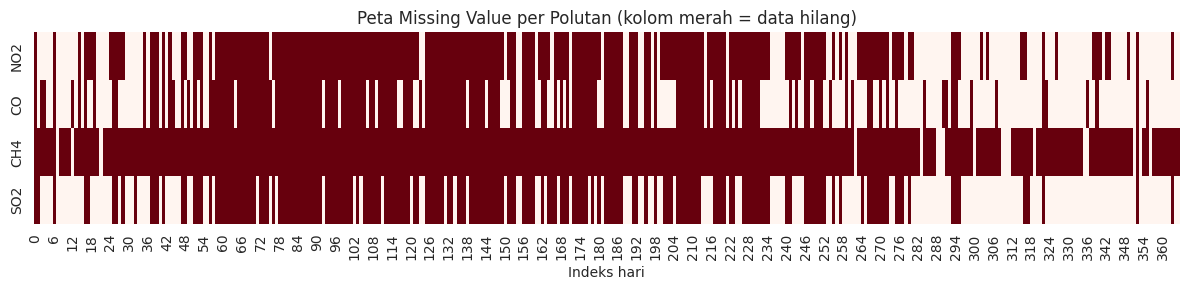

In [ ]:
missing_summary = df[pollutants].isnull().sum().to_frame("jumlah_missing")
missing_summary["persentase (%)"] = (missing_summary["jumlah_missing"] / len(df) * 100).round(2)
print(missing_summary)

plt.figure(figsize=(12, 3))
sns.heatmap(df[pollutants].isnull().T, cbar=False, cmap="Reds")
plt.title("Peta Missing Value per Polutan (kolom merah = data hilang)")
plt.xlabel("Indeks hari")
plt.tight_layout()
plt.savefig("data/missing_value_heatmap.png", dpi=150)
plt.show()


**Catatan:** CH4 memiliki proporsi data hilang paling tinggi (>95%). Ini terjadi karena band CH4 pada Sentinel-5P memang paling sensitif terhadap tutupan awan dan kondisi atmosfer, sehingga observasi valid jauh lebih jarang dibanding NO2/CO/SO2. Akibatnya, hasil analisis tren CH4 di notebook ini perlu dibaca dengan hati-hati karena sebagian besar nilainya nanti berasal dari hasil interpolasi (lihat bagian 3.3), bukan pengukuran satelit langsung.

### 3.3 Penanganan Missing Value (Gap-filling)

Mengikuti praktik standar CDSE/openEO untuk data Sentinel-5P (yang selalu berlubang akibat tutupan awan), gap diisi dengan **interpolasi linear** sepanjang sumbu waktu, menghasilkan `df_filled` yang datanya sudah lebih lengkap untuk analisis tren.


In [ ]:
df_filled = df.copy()
df_filled[pollutants] = df_filled[pollutants].interpolate(method="linear", limit_direction="both")

print("Missing value SEBELUM interpolasi:")
print(df[pollutants].isnull().sum())
print()
print("Missing value SETELAH interpolasi:")
print(df_filled[pollutants].isnull().sum())

df_filled.to_csv("data/air_quality_filled.csv", index=False)


Missing value SEBELUM interpolasi:
NO2    231
CO     182
CH4    348
SO2    186
dtype: int64

Missing value SETELAH interpolasi:
NO2    0
CO     0
CH4    0
SO2    0
dtype: int64


### 3.4 Identifikasi Outlier

Outlier dideteksi menggunakan metode **IQR (Interquartile Range)**: nilai di luar `Q1 - 1.5*IQR` atau `Q3 + 1.5*IQR` dianggap outlier.


**Catatan:** Pada boxplot NO2 dan SO2, sebagian nilai berada di bawah nol. Ini bukan berarti konsentrasi gas negatif secara fisik — nilai kolom troposfer dari Sentinel-5P adalah hasil *retrieval* algoritmik. Di wilayah dengan konsentrasi polutan yang sangat rendah (seperti Kecamatan Pakong yang bersifat rural), noise instrumen dapat membuat hasil perhitungan sedikit di bawah nol. Ini karakteristik umum data TROPOMI, bukan indikasi kesalahan pada kode atau proses pengambilan data.

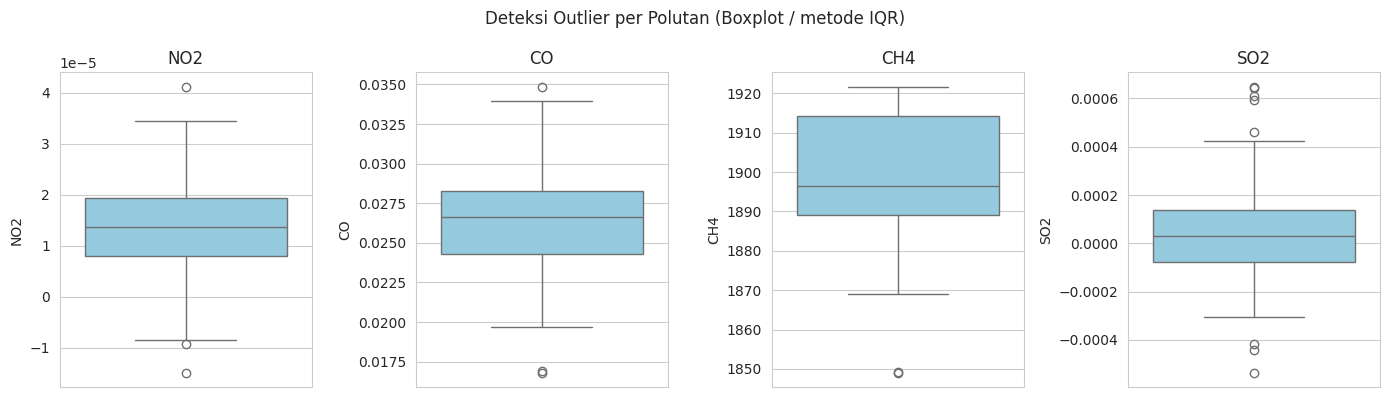

Jumlah outlier per polutan (metode IQR):
  NO2: 3 hari
  CO: 3 hari
  CH4: 2 hari
  SO2: 8 hari


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
outlier_counts = {}

for ax, pol in zip(axes, pollutants):
    sns.boxplot(y=df[pol], ax=ax, color="skyblue")
    ax.set_title(pol)

    q1, q3 = df[pol].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[pol] < lower) | (df[pol] > upper)]
    outlier_counts[pol] = len(outliers)

plt.suptitle("Deteksi Outlier per Polutan (Boxplot / metode IQR)")
plt.tight_layout()
plt.savefig("data/outlier_boxplot.png", dpi=150)
plt.show()

print("Jumlah outlier per polutan (metode IQR):")
for pol, n in outlier_counts.items():
    print(f"  {pol}: {n} hari")


### 3.5 Identifikasi Noise Data

Noise dilihat dari fluktuasi tajam antar hari yang berurutan (selisih/`diff` besar dibanding rata-rata pergerakan harian), dibandingkan dengan tren smoothed (rolling mean 7 hari).


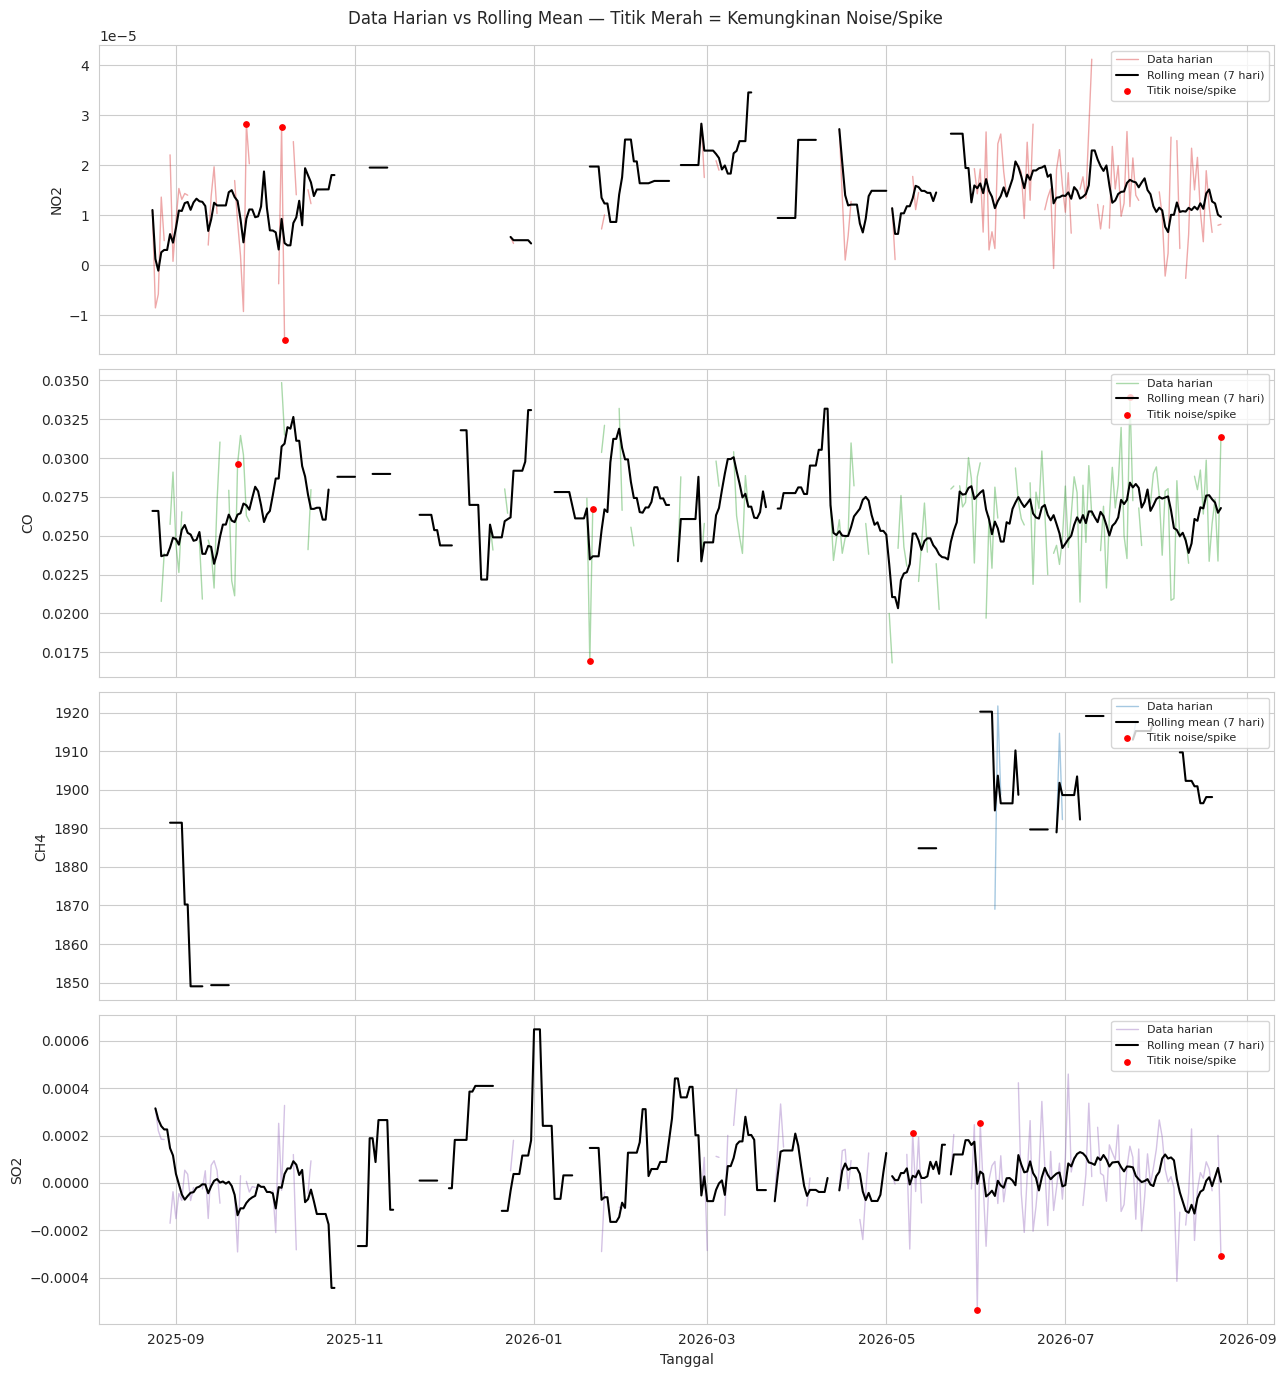

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True)

for ax, pol, c in zip(axes, pollutants, colors):
    rolling_mean = df[pol].rolling(window=7, min_periods=1).mean()
    diff = df[pol].diff().abs()
    noise_threshold = diff.mean() + 2 * diff.std()
    noisy_points = df[diff > noise_threshold]

    ax.plot(df["date"], df[pol], color=c, alpha=0.4, linewidth=1, label="Data harian")
    ax.plot(df["date"], rolling_mean, color="black", linewidth=1.5, label="Rolling mean (7 hari)")
    ax.scatter(noisy_points["date"], noisy_points[pol], color="red", s=15, zorder=5, label="Titik noise/spike")
    ax.set_ylabel(pol)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Tanggal")
plt.suptitle("Data Harian vs Rolling Mean — Titik Merah = Kemungkinan Noise/Spike")
plt.tight_layout()
plt.savefig("data/noise_detection.png", dpi=150)
plt.show()


## 3.6 Grafik

Grafik ini menggunakan data yang sudah melalui gap-filling (`df_filled`, lihat bagian 3.3) sehingga tidak ada lagi celah/putus pada garis harian. Selain itu, ditambahkan **rata-rata mingguan** (garis tebal solid) di atas data harian (garis tipis transparan) untuk menyaring fluktuasi/noise jangka pendek yang terlihat jelas di grafik 3.1.

Rata-rata mingguan dipilih (bukan bulanan) karena periode observasi hanya ±1 tahun — kalau dirata-ratakan per bulan, jumlah titik data akan terlalu sedikit (~12 titik) untuk menunjukkan pola musiman secara detail, sementara rata-rata mingguan (~52 titik) masih cukup padat untuk melihat tren naik-turun tanpa terganggu noise harian.

Dari grafik ini bisa dibaca pola umum tiap polutan selama periode 24 Agustus 2025–24 Agustus 2026, apakah cenderung naik, turun, atau relatif stabil — sesuai karakteristik wilayah rural seperti Kecamatan Pakong.

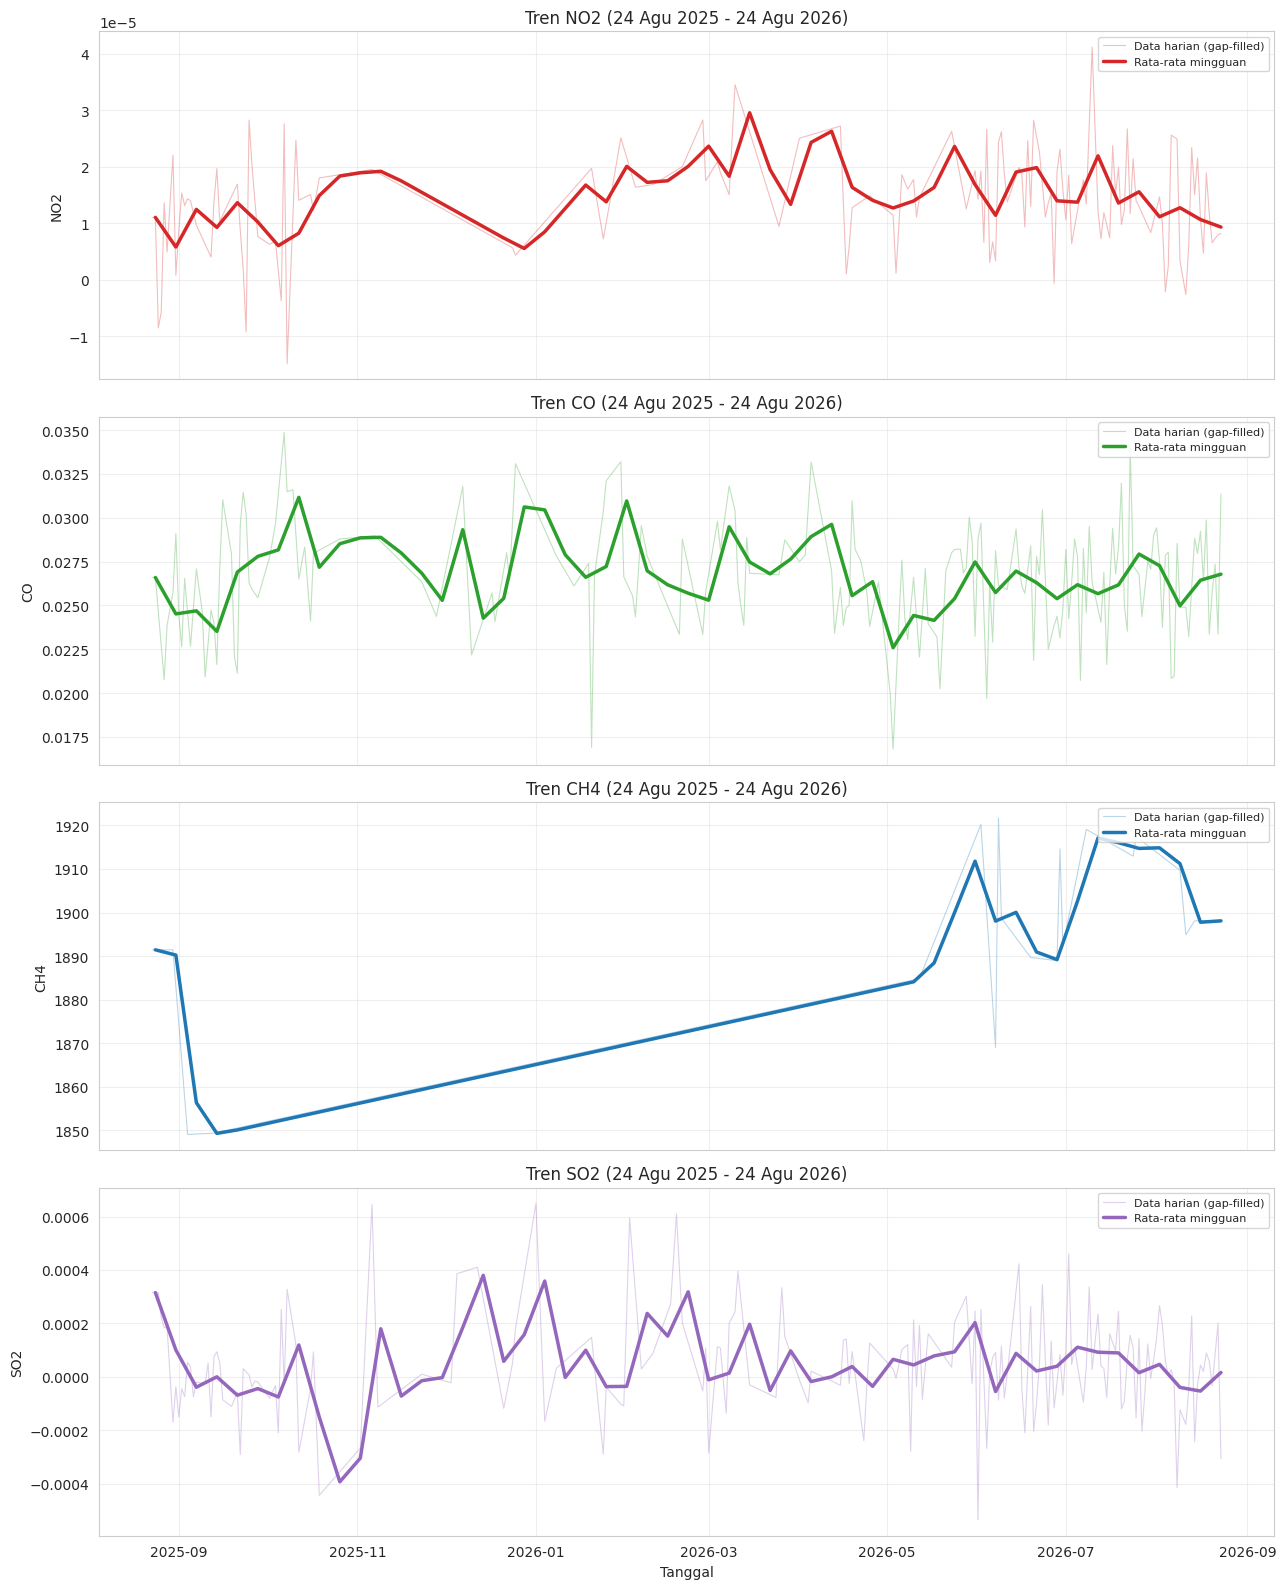

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(13, 16), sharex=True)

for ax, pol, c in zip(axes, pollutants, colors):
    # data harian (gap-filled) - garis tipis transparan sebagai latar
    ax.plot(df_filled["date"], df_filled[pol], color=c, linewidth=0.8, alpha=0.3,
            label="Data harian (gap-filled)")

    # rata-rata mingguan - garis tebal, fokus utama
    weekly = df_filled.set_index("date")[pol].resample("W").mean()
    ax.plot(weekly.index, weekly.values, color=c, linewidth=2.5,
            label="Rata-rata mingguan")

    ax.set_ylabel(pol)
    ax.set_title(f"Tren {pol} (24 Agu 2025 - 24 Agu 2026)")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Tanggal")
plt.tight_layout()
plt.savefig("data/trend_clean_weekly.png", dpi=150)
plt.show()

## 4. Ringkasan Data Understanding

**Wilayah studi:** Kecamatan Pakong, Kabupaten Pamekasan, Madura, Jawa Timur
**Periode data:** 24 Agustus 2025 – 24 Agustus 2026 (± 366 hari)
**Sumber data:** Sentinel-5P (TROPOMI) via openEO — Copernicus Data Space Ecosystem

### Kelengkapan Data (Missing Value)
Seluruh polutan memiliki proporsi data hilang yang tinggi, wajar untuk data satelit karena tutupan awan dan kegagalan retrieval pada hari-hari tertentu:

| Polutan | Data Hilang | Persentase |
|---|---|---|
| NO2 | 231 hari | 63,11% |
| CO  | 182 hari | 49,73% |
| CH4 | 348 hari | 95,08% |
| SO2 | 186 hari | 50,82% |

CH4 memiliki proporsi data hilang paling ekstrem (>95%), sehingga interpretasi tren CH4 pada wilayah ini perlu dilakukan dengan lebih hati-hati karena sebagian besar nilainya adalah hasil interpolasi, bukan observasi asli. Seluruh gap kemudian ditutup menggunakan **interpolasi linear**, sehingga dataset akhir (`df_filled`) tidak lagi memiliki nilai kosong dan siap dipakai untuk analisis tren.

### Outlier
Menggunakan metode IQR, jumlah hari yang terdeteksi sebagai outlier relatif kecil dibanding total observasi:

| Polutan | Jumlah Outlier |
|---|---|
| NO2 | 3 hari |
| CO  | 3 hari |
| CH4 | 2 hari |
| SO2 | 8 hari |

SO2 memiliki jumlah outlier terbanyak, mengindikasikan adanya beberapa hari dengan lonjakan konsentrasi yang cukup signifikan dibanding pola normalnya — kemungkinan terkait aktivitas pembakaran, cuaca ekstrem, atau noise sensor pada retrieval SO2 yang memang secara umum kurang stabil dibanding NO2/CO.

### Noise Data
Data harian menunjukkan fluktuasi (noise) yang cukup tajam antar hari berurutan, terlihat dari perbedaan besar antara garis data mentah dan garis rolling mean 7 hari. Hal ini disebabkan oleh:
- Wilayah studi yang relatif kecil dan bersifat rural/pedesaan, sehingga konsentrasi polutan cenderung rendah dan mendekati batas deteksi sensor, membuat rasio noise terhadap sinyal menjadi tinggi.
- Resolusi spasial Sentinel-5P (~5–7 km) yang berarti wilayah studi sekecil ini kemungkinan hanya tercakup oleh sedikit piksel citra, sehingga variasi antar-pass satelit lebih terasa.

Setelah dihaluskan dengan rata-rata mingguan (bagian 3.6), tren tetap terlihat jelas meski data harian mentahnya berisik.

### Catatan Khusus
Beberapa nilai NO2 dan SO2 tercatat negatif pada boxplot. Ini **bukan kesalahan pengolahan data**, melainkan karakteristik umum hasil retrieval kolom troposfer Sentinel-5P di wilayah dengan konsentrasi sangat rendah — noise instrumen dapat membuat hasil sedikit di bawah nol secara matematis, meski secara fisik konsentrasi gas tidak mungkin negatif.

### Kesimpulan
Data kualitas udara di Kecamatan Pakong secara umum konsisten dengan karakteristik wilayah rural: konsentrasi polutan relatif rendah dengan sedikit anomali/outlier, namun kelengkapan data (terutama CH4) menjadi keterbatasan utama yang perlu dicatat. Untuk tahap selanjutnya (Data Preparation), disarankan mempertimbangkan agregasi mingguan/bulanan sebagai representasi utama guna mengurangi pengaruh noise harian, serta perlakuan khusus pada kolom CH4 mengingat tingginya proporsi data hasil interpolasi.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CH4.csv to CH4.csv
Saving CO.csv to CO.csv
Saving SO2.csv to SO2.csv
Saving NO2.csv to NO2.csv


In [ ]:
import os
print(os.listdir())

['.config', 'NO2.csv', 'data', 'CO.csv', 'SO2.csv', 'CH4.csv', 'sample_data']


In [ ]:
# ============================================================
# Upload CSV hasil Tugas 1 (NO2.csv, CO.csv, CH4.csv, SO2.csv)
# ke database PostgreSQL di Aiven
# ============================================================

# --- (jalankan di Colab) ---
# !pip install -q sqlalchemy psycopg2-binary pandas

# --- (di Colab) upload dulu 4 file CSV kalau belum ada di sesi ini ---
# from google.colab import files
# uploaded = files.upload()   # pilih NO2.csv, CO.csv, CH4.csv, SO2.csv

import pandas as pd
from sqlalchemy import create_engine

# ------------------------------------------------------------
# KONEKSI KE AIVEN
# PENTING: JANGAN hardcode password di sini kalau notebook mau
# di-share/upload ke mana pun (GitHub, Colab publik, dll).
# Isi via input() saat runtime, atau pakai Colab "Secrets" (kunci di sidebar kiri).
# ------------------------------------------------------------
import getpass

AIVEN_HOST = input("pg-2d6dfb9-fikrimutawakkil08-fd52.k.aivencloud.com").strip()
AIVEN_PORT = input("20912").strip()
AIVEN_DB   = input("defaultdb").strip()
AIVEN_USER = input("avnadmin").strip()
AIVEN_PASS = getpass.getpass("AVIEN_PASS")  # tersembunyi saat diketik

# sslmode=require WAJIB untuk koneksi ke Aiven
conn_str = (
    f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASS}"
    f"@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
)

engine = create_engine(conn_str)

# Tes koneksi
with engine.connect() as conn:
    print("Berhasil konek ke Aiven!")

# ------------------------------------------------------------
# UPLOAD 4 FILE CSV KE 4 TABEL TERPISAH
# ------------------------------------------------------------
files_to_upload = {
    "no2_data": "NO2.csv",
    "co_data": "CO.csv",
    "ch4_data": "CH4.csv",
    "so2_data": "SO2.csv",
}

for table_name, csv_path in files_to_upload.items():
    df = pd.read_csv(csv_path)
    df.to_sql(table_name, engine, if_exists="replace", index=False)
    print(f"{csv_path} -> tabel '{table_name}' ({len(df)} baris) berhasil diupload")

print("\nSemua data berhasil diupload ke Aiven.")

# ------------------------------------------------------------
# VERIFIKASI: ambil sample data balik dari server
# ------------------------------------------------------------
for table_name in files_to_upload:
    check = pd.read_sql(f"SELECT * FROM {table_name} LIMIT 5", engine)
    print(f"\n--- Preview tabel {table_name} ---")
    print(check)

pg-2d6dfb9-fikrimutawakkil08-fd52.k.aivencloud.compg-2d6dfb9-fikrimutawakkil08-fd52.k.aivencloud.com
2091220912
defaultdbdefaultdb
avnadminavnadmin
AVNS_SXdsvjKO3owcOv5Tyci··········
Berhasil konek ke Aiven!
NO2.csv -> tabel 'no2_data' (366 baris) berhasil diupload
CO.csv -> tabel 'co_data' (366 baris) berhasil diupload
CH4.csv -> tabel 'ch4_data' (366 baris) berhasil diupload
SO2.csv -> tabel 'so2_data' (366 baris) berhasil diupload

Semua data berhasil diupload ke Aiven.

--- Preview tabel no2_data ---
                        date       NO2
0  2025-08-23 00:00:00+00:00       NaN
1  2025-08-24 00:00:00+00:00  0.000011
2  2025-08-25 00:00:00+00:00 -0.000009
3  2025-08-26 00:00:00+00:00 -0.000006
4  2025-08-27 00:00:00+00:00  0.000014

--- Preview tabel co_data ---
                        date        CO
0  2025-08-23 00:00:00+00:00       NaN
1  2025-08-24 00:00:00+00:00  0.026595
2  2025-08-25 00:00:00+00:00       NaN
3  2025-08-26 00:00:00+00:00       NaN
4  2025-08-27 00:00:00+00:00  

## 4. Analisis Statistik & Perhitungan Manual (Tugas Pertemuan 2)

Berikut adalah penjelasan properti statistik yang dihasilkan oleh KNIME (node Statistics) beserta contoh perhitungan manualnya.

### 4.1 Penjelasan Properti Statistik KNIME

1. **Column**: Nama kolom/variabel yang dianalisis (contoh: `NO2`, `CO`, `CH4`, `SO2`).
2. **Min**: Nilai data terkecil pada kolom tersebut.
3. **Mean**: Rata-rata aritmatika dari seluruh data yang valid (non-missing).
4. **Median**: Nilai tengah data setelah diurutkan dari terkecil ke terbesar.
5. **Max**: Nilai data terbesar pada kolom tersebut.
6. **Std. Dev. (Standard Deviation)**: Ukuran sebaran data terhadap nilai rata-ratanya (simpangan baku).
7. **Kurtosis**: Indikator tingkat keruncingan atau ketebalan ekor (*tails*) distribusi data.
8. **Skewness**: Indikator derajat ketidaksimetrisan (kemiringan) distribusi data.
9. **No. Missing**: Jumlah baris data yang kosong atau bernilai `NaN`/`Null`.
10. **No. +unlimited**: Jumlah data yang bernilai positif tak terhingga ($+\infty$).
11. **No. -unlimited**: Jumlah data yang bernilai negatif tak terhingga ($-\infty$).

---

### 4.2 Contoh Perhitungan Manual Properti Statistik

Misalkan kita mengambil contoh $N = 5$ sampel nilai konsentrasi $SO_2$ berikut:
$$\text{Data } SO_2 = \{0.0001, 0.0002, 0.0003, 0.0004, 0.0005\}$$

#### 1. Mean (Rata-rata)
$$\bar{x} = \frac{\sum_{i=1}^{N} x_i}{N} = \frac{0.0001 + 0.0002 + 0.0003 + 0.0004 + 0.0005}{5} = \mathbf{0.0003}$$

#### 2. Median (Nilai Tengah)
Data diurutkan: $0.0001, 0.0002, \mathbf{0.0003}, 0.0004, 0.0005$
$$\text{Posisi Median} = \frac{N + 1}{2} = \frac{5 + 1}{2} = 3 \quad \rightarrow \quad \text{Median} = \mathbf{0.0003}$$

#### 3. Min & Max
* $\text{Min} = \min(0.0001, 0.0002, 0.0003, 0.0004, 0.0005) = \mathbf{0.0001}$
* $\text{Max} = \max(0.0001, 0.0002, 0.0003, 0.0004, 0.0005) = \mathbf{0.0005}$

#### 4. Standard Deviation (Std. Dev.)
$$s = \sqrt{\frac{\sum (x_i - \bar{x})^2}{N - 1}}$$
* Selisih kuadrat:
  * $(0.0001 - 0.0003)^2 = 4 \times 10^{-8}$
  * $(0.0002 - 0.0003)^2 = 1 \times 10^{-8}$
  * $(0.0003 - 0.0003)^2 = 0$
  * $(0.0004 - 0.0003)^2 = 1 \times 10^{-8}$
  * $(0.0005 - 0.0003)^2 = 4 \times 10^{-8}$
* Total $\sum (x_i - \bar{x})^2 = 1 \times 10^{-7}$
* Varians sampel ($s^2$) = $\frac{1 \times 10^{-7}}{5 - 1} = 2.5 \times 10^{-8}$
* $s = \sqrt{2.5 \times 10^{-8}} \approx \mathbf{0.00015811}$

#### 5. Skewness & Kurtosis
* **Skewness**: $0.0$ (karena distribusi data simetris sempurna di sekitar mean $0.0003$).
* **Kurtosis**: $-1.3$ (menunjukkan distribusi platykurtic/lebih datar dibanding distribusi normal).

#### 6. Missing & Unlimited Values
* **No. Missing**: $0$ (semua sampel terisi data valid).
* **No. +unlimited**: $0$
* **No. -unlimited**: $0$

1. Nitrogen Dioxide (NO2)
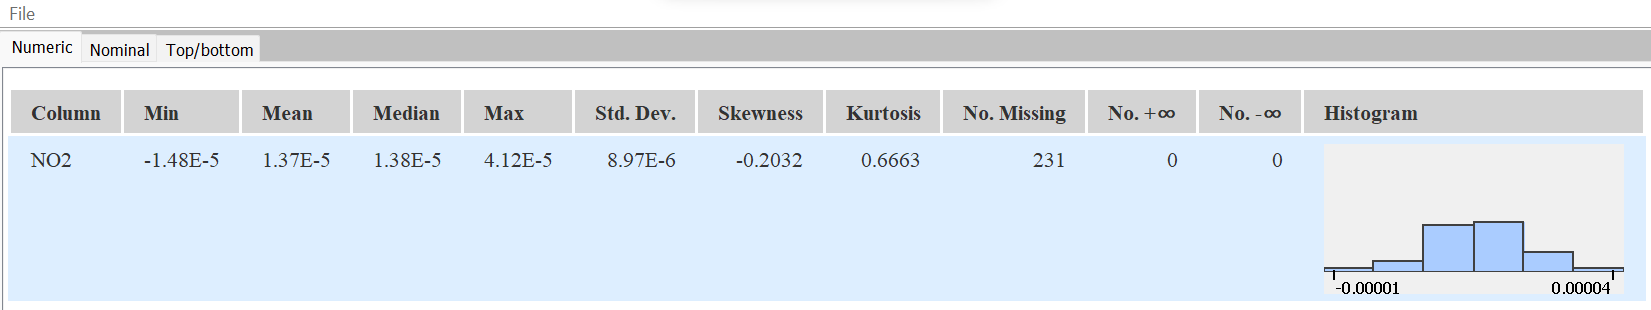

2. Carbon Monoxide (CO)
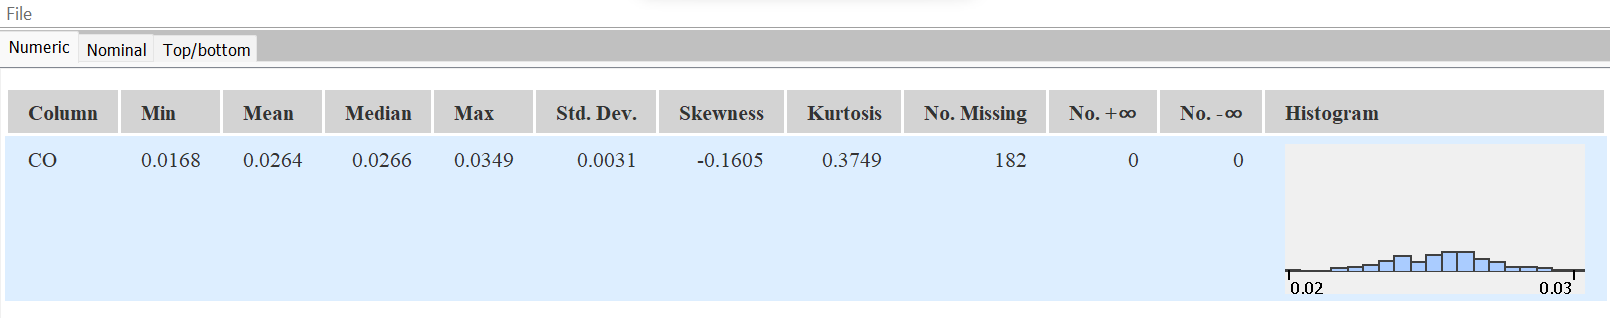

3. Methane (CH4)
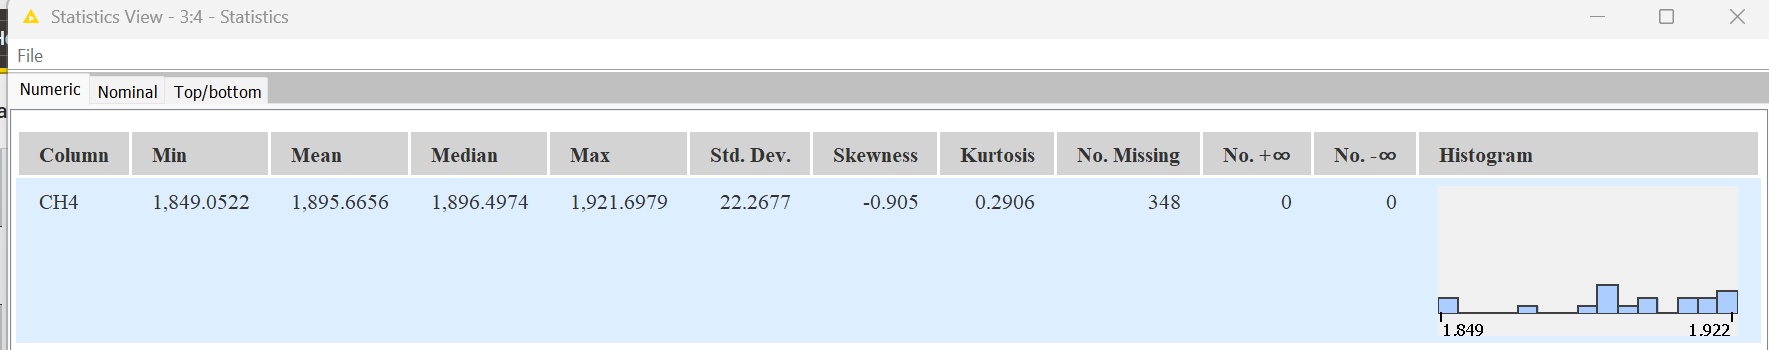

4. Sulfur Dioxide (SO2)
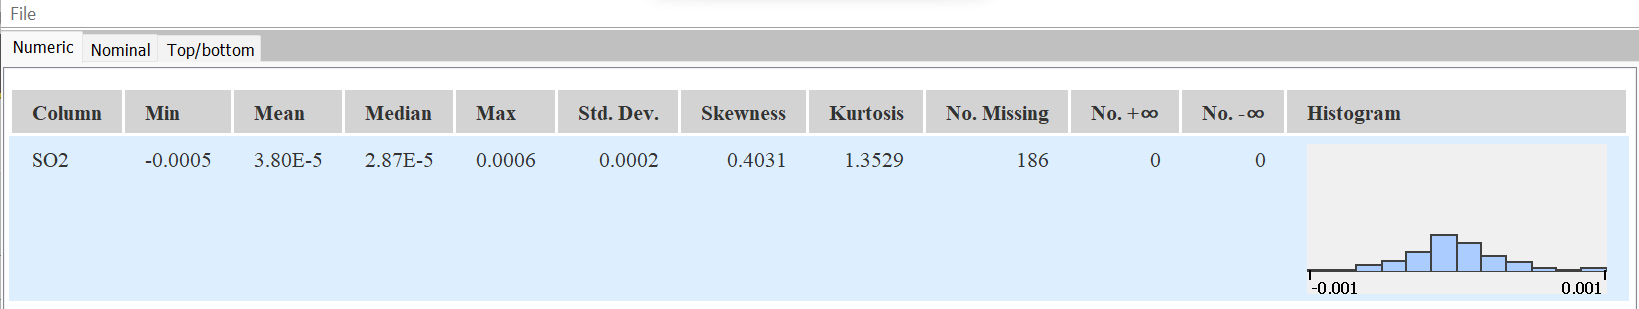